<a href="https://colab.research.google.com/github/kjm5416-ship-it/-secom-anomaly-detection/blob/main/03_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

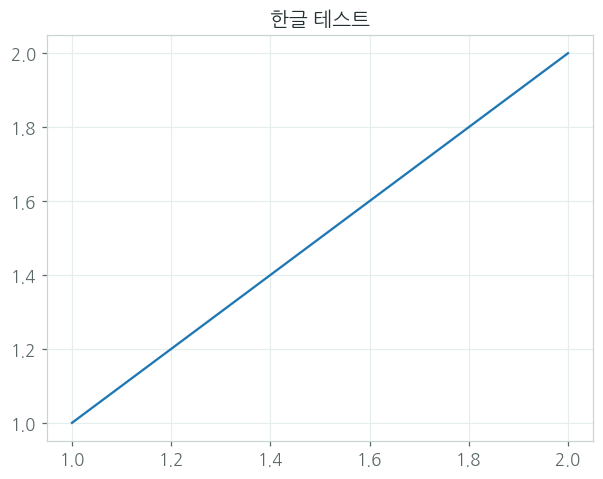

In [ ]:
!apt-get -qq install fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import FuncFormatter

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

TEAL, RED, GRAY, INK = '#0E6B75', '#B23A2B', '#8A9698', '#233033'
plt.rcParams.update({
    'figure.dpi':110, 'savefig.dpi':160, 'font.size':11,
    'axes.edgecolor':'#C9D4D4', 'axes.labelcolor':INK, 'text.color':INK,
    'xtick.color':'#5A6768', 'ytick.color':'#5A6768',
    'axes.grid':True, 'grid.color':'#E6EDED', 'grid.linewidth':.8,
    'axes.axisbelow':True, 'figure.facecolor':'white', 'axes.facecolor':'white'})

plt.plot([1,2],[1,2]); plt.title('한글 테스트'); plt.show()

In [ ]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

url = "https://raw.githubusercontent.com/sharmaroshan/SECOM-Detecting-Defected-Items/master/uci-secom.csv"
df = pd.read_csv(url)

X_raw = df.drop(columns=['Time', 'Pass/Fail'])
y = (df['Pass/Fail'] == 1).astype(int)

X = X_raw.drop(columns=X_raw.columns[X_raw.nunique() <= 1])
X = X.drop(columns=X.columns[X.isna().mean() > 0.5])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
y_train = y_train.reset_index(drop=True)

print("준비 완료:", X_train_s.shape)

준비 완료: (1253, 446)


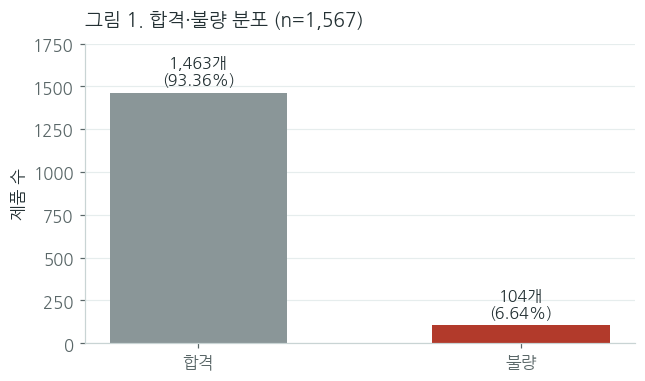

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.6))
cnt = [int((y==0).sum()), int((y==1).sum())]
bars = ax.bar(['합격','불량'], cnt, color=[GRAY, RED], width=.55)
for r, c in zip(bars, cnt):
    ax.text(r.get_x()+r.get_width()/2, c+30, f'{c:,}개\n({c/len(y)*100:.2f}%)',
            ha='center', va='bottom', fontsize=10.5)
ax.set_ylim(0, 1750); ax.set_ylabel('제품 수')
ax.set_title('그림 1. 합격·불량 분포 (n=1,567)', loc='left', fontsize=12.5, pad=12)
ax.spines[['top','right']].set_visible(False); ax.grid(axis='x', visible=False)
plt.tight_layout(); plt.savefig('그림1_불량비율.png', bbox_inches='tight'); plt.show()

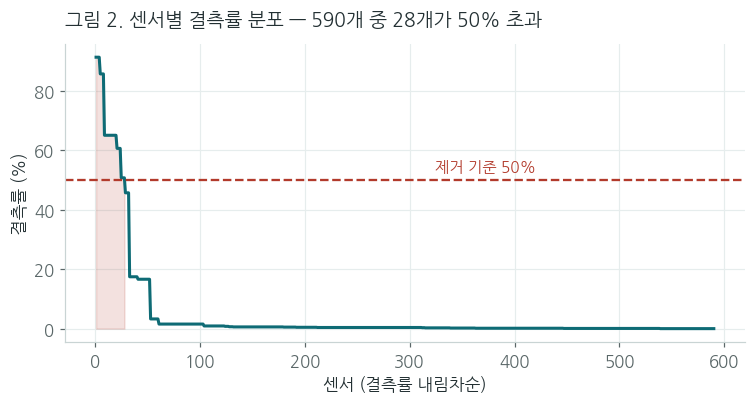

In [ ]:
miss = (X_raw.isna().mean()*100).sort_values(ascending=False).values

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(range(1, len(miss)+1), miss, color=TEAL, lw=2)
ax.axhline(50, color=RED, lw=1.5, ls='--')
ax.text(len(miss)*.55, 53, '제거 기준 50%', color=RED, fontsize=10)
ax.fill_between(range(1, len(miss)+1), miss, where=(miss>50), color=RED, alpha=.15)
ax.set_xlabel('센서 (결측률 내림차순)'); ax.set_ylabel('결측률 (%)')
ax.set_title('그림 2. 센서별 결측률 분포 — 590개 중 28개가 50% 초과', loc='left', fontsize=12.5, pad=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('그림2_결측분포.png', bbox_inches='tight'); plt.show()

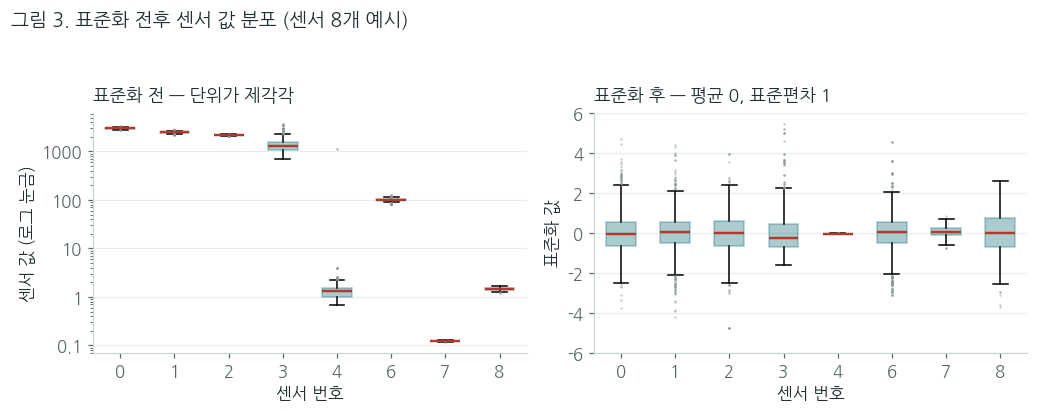

In [ ]:
cols = list(X.columns[:8])
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))

for ax, data, t in zip(axes, [X_train[cols], X_train_s[cols]],
                       ['표준화 전 — 단위가 제각각', '표준화 후 — 평균 0, 표준편차 1']):
    bp = ax.boxplot([data[c].values for c in cols], tick_labels=cols, patch_artist=True, widths=.55,
                    flierprops=dict(marker='.', markersize=3, markerfacecolor=GRAY,
                                    markeredgecolor='none', alpha=.5))
    for p in bp['boxes']:   p.set_facecolor(TEAL); p.set_alpha(.35); p.set_edgecolor(TEAL)
    for p in bp['medians']: p.set_color(RED); p.set_linewidth(1.6)
    ax.set_title(t, loc='left', fontsize=11.5, pad=8); ax.set_xlabel('센서 번호')
    ax.spines[['top','right']].set_visible(False); ax.grid(axis='x', visible=False)

axes[0].set_yscale('log'); axes[0].set_ylabel('센서 값 (로그 눈금)')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}'))
axes[0].yaxis.set_minor_formatter(FuncFormatter(lambda v, _: ''))
axes[1].set_ylim(-6, 6); axes[1].set_ylabel('표준화 값')
fig.suptitle('그림 3. 표준화 전후 센서 값 분포 (센서 8개 예시)', x=.01, ha='left', fontsize=12.5)
plt.tight_layout(rect=[0,0,1,.93]); plt.savefig('그림3_표준화.png', bbox_inches='tight'); plt.show()

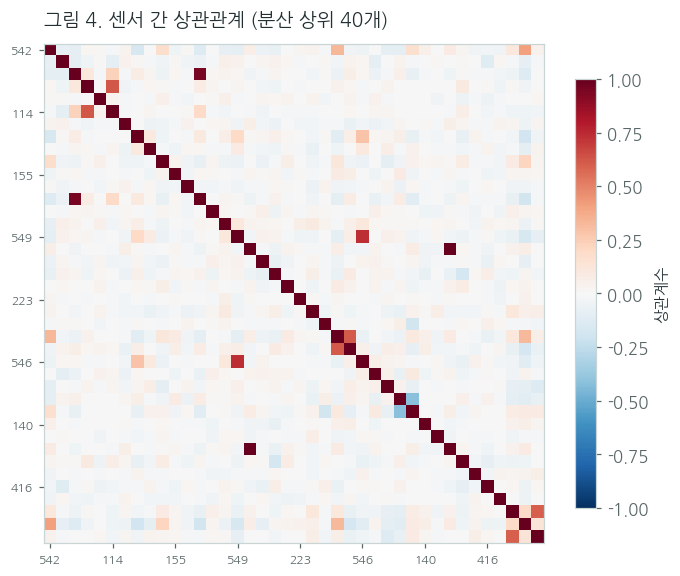

|상관| > 0.9인 센서 쌍: 2 개


In [ ]:
top = X_train_s.var().sort_values(ascending=False).index[:40]
corr = X_train_s[top].corr()

fig, ax = plt.subplots(figsize=(6.4, 5.4))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(0,40,5)); ax.set_xticklabels(top[::5], fontsize=8)
ax.set_yticks(range(0,40,5)); ax.set_yticklabels(top[::5], fontsize=8)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, shrink=.82); cb.set_label('상관계수', fontsize=10)
ax.set_title('그림 4. 센서 간 상관관계 (분산 상위 40개)', loc='left', fontsize=12.5, pad=12)
plt.tight_layout(); plt.savefig('그림4_상관관계.png', bbox_inches='tight'); plt.show()

pairs = corr.where(~np.eye(40, dtype=bool)).abs()
print("|상관| > 0.9인 센서 쌍:", int((pairs > 0.9).sum().sum() / 2), "개")

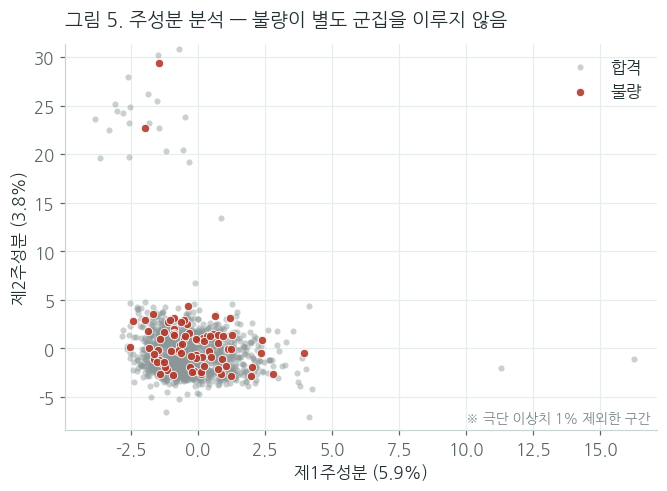

두 주성분이 설명하는 비율: 9.7%


In [ ]:
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X_train_s)

fig, ax = plt.subplots(figsize=(6.2, 4.6))
ax.scatter(Z[y_train==0,0], Z[y_train==0,1], s=16, c=GRAY, alpha=.45, linewidths=0, label='합격')
ax.scatter(Z[y_train==1,0], Z[y_train==1,1], s=30, c=RED, alpha=.9,
           linewidths=.6, edgecolors='white', label='불량')

xl = np.percentile(Z[:,0], [.5, 99.5]); yl = np.percentile(Z[:,1], [.5, 99.5])
mx = (xl[1]-xl[0])*.12; my = (yl[1]-yl[0])*.12
ax.set_xlim(xl[0]-mx, xl[1]+mx); ax.set_ylim(yl[0]-my, yl[1]+my)

ax.set_xlabel(f'제1주성분 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'제2주성분 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(frameon=False, loc='upper right')
ax.set_title('그림 5. 주성분 분석 — 불량이 별도 군집을 이루지 않음', loc='left', fontsize=12.5, pad=12)
ax.text(.99, .02, '※ 극단 이상치 1% 제외한 구간', transform=ax.transAxes,
        ha='right', fontsize=9, color='#7A8688')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('그림5_PCA.png', bbox_inches='tight'); plt.show()

print("두 주성분이 설명하는 비율: %.1f%%" % (pca.explained_variance_ratio_[:2].sum()*100))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
path = '/content/drive/MyDrive/도전학기/그림'
os.makedirs(path, exist_ok=True)

for f in ['그림1_불량비율.png','그림2_결측분포.png','그림3_표준화.png','그림4_상관관계.png','그림5_PCA.png']:
    shutil.move(f, f'{path}/{f}')

print(os.listdir(path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['그림1_불량비율.png', '그림2_결측분포.png', '그림3_표준화.png', '그림4_상관관계.png', '그림5_PCA.png']
